In [161]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [162]:
df=pd.read_csv('Student_Performance.csv')

In [163]:
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [164]:
x=df.drop(columns='Performance Index')
y=df['Performance Index']

In [165]:
num_cols=x.select_dtypes(include='number').columns
obj_cols= x.select_dtypes(include='object').columns

<Axes: >

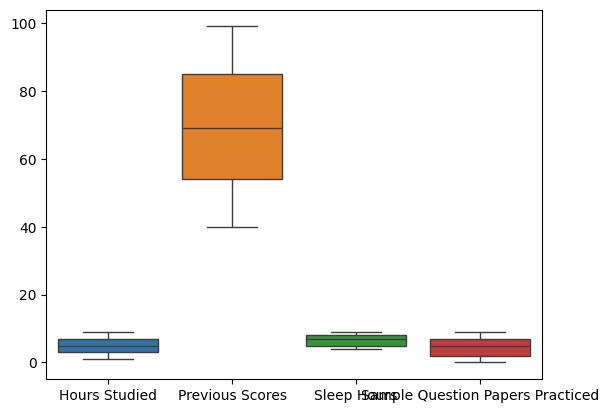

In [166]:
sns.boxplot(x[num_cols])

#### If we get dots on any box then we confirm that it has outlayers

#### By using boxplot only we can check the outlayers

In [167]:
xtrain, ytrain, xtest, ytest=train_test_split(x,y, train_size=0.8, random_state=42)

In [168]:
scaling=MinMaxScaler()
xtrain[num_cols]=scaling.fit_transform(xtrain[num_cols])
xtrain

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
9254,0.500,0.152542,No,0.6,0.555556
1561,0.125,0.135593,Yes,0.6,0.666667
1670,0.125,0.694915,No,0.6,0.222222
6087,0.125,0.101695,No,0.4,0.111111
6669,0.875,0.118644,No,1.0,0.000000
...,...,...,...,...,...
5734,0.875,0.169492,Yes,0.4,0.666667
5191,0.375,0.474576,No,1.0,0.333333
5390,1.000,0.135593,No,0.6,0.666667
860,0.000,0.118644,No,1.0,0.000000


In [169]:
df.corr(numeric_only=True)

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.012390,0.001245,0.017463,0.373730
Previous Scores,-0.012390,1.000000,0.005944,0.007888,0.915189
Sleep Hours,0.001245,0.005944,1.000000,0.003990,0.048106
Sample Question Papers Practiced,0.017463,0.007888,0.003990,1.000000,0.043268
Performance Index,0.373730,0.915189,0.048106,0.043268,1.000000


In [170]:
xtrain[obj_cols].nunique()

Extracurricular Activities    2
dtype: int64

In [171]:
obj_cols

Index(['Extracurricular Activities'], dtype='object')

In [172]:
# labelEncoder=LabelEncoder()
# xtrain['Extracurricular Activities']=labelEncoder.fit_transform(xtrain[obj_cols])
# xtrain

In [173]:
hotEncoder=OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# xtrain[obj_cols]=hotEncoder.fit_transform(xtrain[obj_cols])
values=hotEncoder.fit_transform(xtrain[obj_cols])
cols=hotEncoder.get_feature_names_out()

In [174]:
xtrain[cols]=values
xtrain.drop(columns=['Extracurricular Activities'], inplace=True)

In [175]:
xtrain

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Extracurricular Activities_No,Extracurricular Activities_Yes
9254,0.500,0.152542,0.6,0.555556,1.0,0.0
1561,0.125,0.135593,0.6,0.666667,0.0,1.0
1670,0.125,0.694915,0.6,0.222222,1.0,0.0
6087,0.125,0.101695,0.4,0.111111,1.0,0.0
6669,0.875,0.118644,1.0,0.000000,1.0,0.0
...,...,...,...,...,...,...
5734,0.875,0.169492,0.4,0.666667,0.0,1.0
5191,0.375,0.474576,1.0,0.333333,1.0,0.0
5390,1.000,0.135593,0.6,0.666667,1.0,0.0
860,0.000,0.118644,1.0,0.000000,1.0,0.0


In [176]:
xtest[num_cols]=scaling.transform(xtest[num_cols])
xtest_values=hotEncoder.transform(xtest[obj_cols])
xtest[cols]=xtest_values
xtest.drop(columns=['Extracurricular Activities'], inplace=True)

KeyError: "None of [Index(['Hours Studied', 'Previous Scores', 'Sleep Hours',\n       'Sample Question Papers Practiced'],\n      dtype='object')] are in the [index]"

In [ ]:
model=LinearRegression()
model.fit(xtrain, ytrain)

ValueError: could not convert string to float: 'No'

In [ ]:
# Evaluation
model.score(xtrain,ytrain)

AttributeError: 'LinearRegression' object has no attribute 'coef_'

In [ ]:
model.score(xtest, ytest)

c:\Users\idris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.